In [1]:
# importing the requisite libraries


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import warnings

warnings.filterwarnings("ignore")

In [2]:
try:
    df = pd.read_csv("Example2.csv")
except TypeError as e:
    print(e)

In [4]:
df.head(10)

,number_courses,time_study,Marks
0,3,4.508,19.202
1,4,0.096,7.734
2,4,3.133,13.811
3,6,7.909,53.018
4,8,7.811,55.299
5,6,3.211,17.822
6,3,6.063,29.889
7,5,3.413,17.264
8,4,4.410,20.348
9,3,6.173,30.862


<Axes: xlabel='number_courses', ylabel='Marks'>

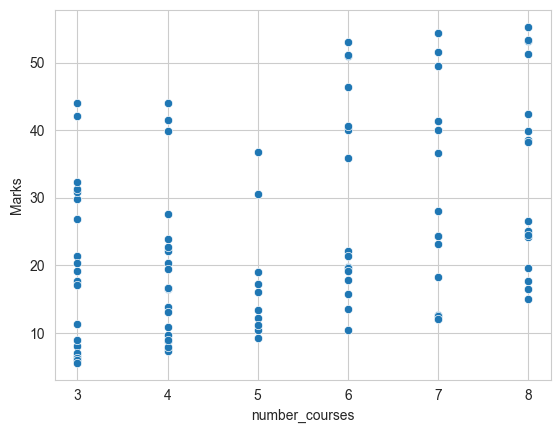

In [5]:
sns.scatterplot(df, x="number_courses", y="Marks")

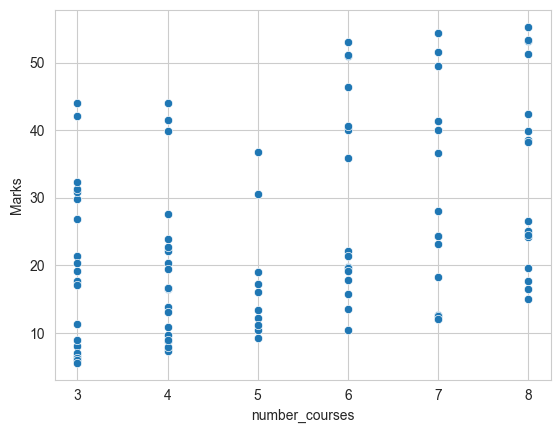

In [9]:
sns.scatterplot(df, x="number_courses", y="Marks")
plt.show()

<Axes: xlabel='time_study', ylabel='Marks'>

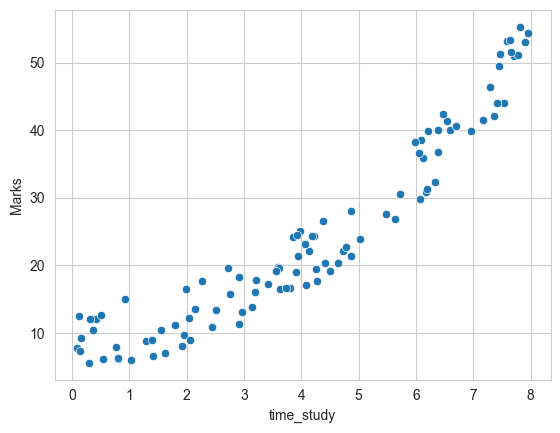

In [10]:
sns.scatterplot(data=df, x="time_study", y="Marks")

In [11]:
X = df[["number_courses", "time_study"]]
y = np.array(df["Marks"]).reshape(-1, 1)

In [12]:
lm = LinearRegression()
lm.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
y_pred = lm.predict(X)

In [14]:
r2_score(y, y_pred)

0.9403656320238896

In [15]:
print(lm.intercept_)
print(lm.coef_)

[-7.45634623]
[[1.86405074 5.39917879]]


In [16]:
# Residual Analysis
res = y - y_pred
rss = np.sum(np.square(y - y_pred))
print(rss)
mse = mean_squared_error(y, y_pred)
print(mse)
rmse = mse**0.5
print(rmse)

1211.6962069108952
12.116962069108952
3.4809426983374707


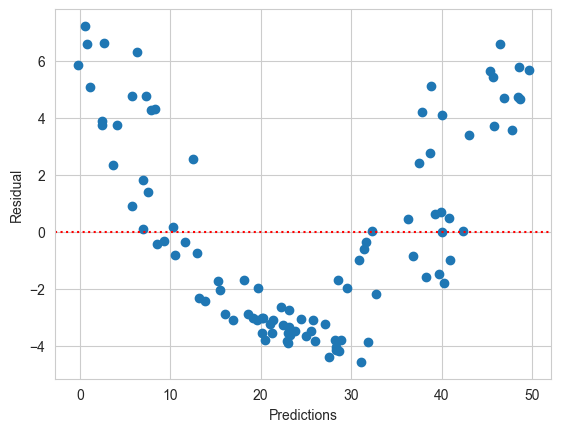

In [17]:
df["res"] = res
plt.scatter(y_pred, df["res"])
plt.axhline(y=0, color="r", linestyle=":")
plt.xlabel("Predictions")
plt.ylabel("Residual")
plt.show()

In [18]:
data = df.copy()
y_res = res

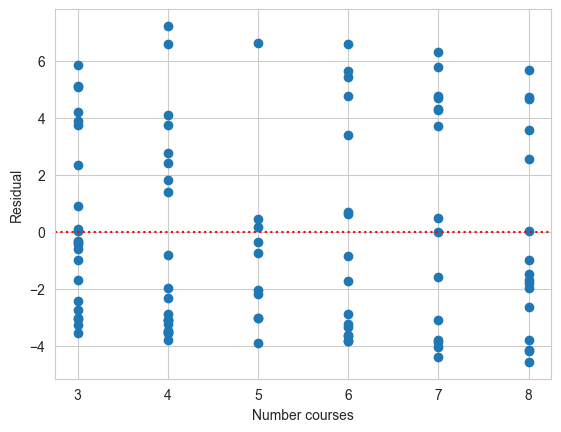

In [19]:
data["res"] = y_res
plt.scatter(data["number_courses"], data["res"])
plt.axhline(y=0, color="r", linestyle=":")
plt.xlabel("Number courses")
plt.ylabel("Residual")
plt.show()

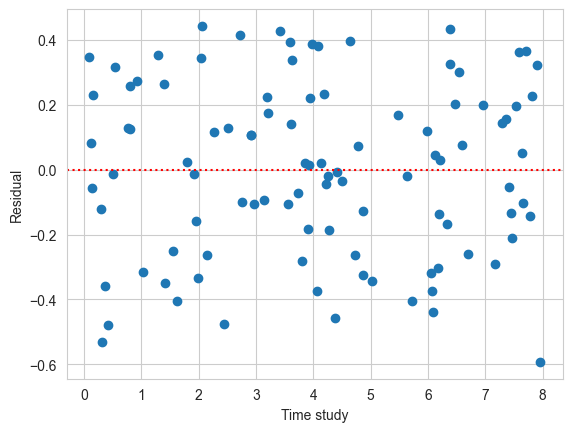

In [46]:
plt.scatter(data["time_study"], data["res"])
plt.axhline(y=0, color="r", linestyle=":")
plt.xlabel("Time study")
plt.ylabel("Residual")
plt.show()

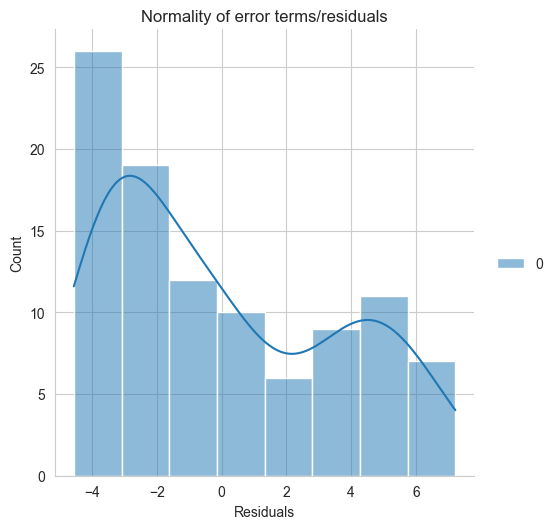

In [21]:
# Distribution of errors
p = sns.displot(y_res, kde=True)

p = plt.title("Normality of error terms/residuals")
plt.xlabel("Residuals")
plt.show()

In [22]:
dfPolynomial = df.copy()

In [23]:
dfPolynomial["time_study_squared"] = (
    dfPolynomial["time_study"] * dfPolynomial["time_study"]
)

In [24]:
dfPolynomial.head(10)

,number_courses,time_study,Marks,res,time_study_squared
0,3,4.508,19.202,-3.273304,20.322064
1,4,0.096,7.734,7.215822,0.009216
2,4,3.133,13.811,-3.104484,9.815689
3,6,7.909,53.018,6.587937,62.552281
4,8,7.811,55.299,5.669955,61.011721
5,6,3.211,17.822,-3.242721,10.310521
6,3,6.063,29.889,-0.982027,36.759969
7,5,3.413,17.264,-3.027305,11.648569
8,4,4.410,20.348,-3.462235,19.448100
9,3,6.173,30.862,-0.602937,38.105929


# Earlier the equation was y=b0+b1x1+b2x2**2, we can write it as y = b0+b1x1+b2x2'

In [35]:
lm_poly = LinearRegression()

## IF we have a higher order term in the polynomial, we need to have it's lower ordered term as well

In [36]:
X = dfPolynomial[["number_courses", "time_study", "time_study_squared"]]
y = dfPolynomial["Marks"]
lm_poly.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [37]:
y_pred = lm_poly.predict(X)

In [38]:
r2_score(y, y_pred)

0.9996529294889802

In [49]:
print(f"Intercept: {lm_poly.intercept_}")
print(f"Coefficents: {lm_poly.coef_}")

Intercept: 0.5629958147295682
Coefficents: [ 1.70546941 -0.02855268  0.67346253]


In [50]:
# Residual Analysis
res = y - y_pred
rss = np.sum(np.square(y - y_pred))
print(rss)
mse = mean_squared_error(y, y_pred)
print(mse)
rmse = mse**0.5
print(rmse)

7.052041230683769
0.07052041230683768
0.26555679676264676


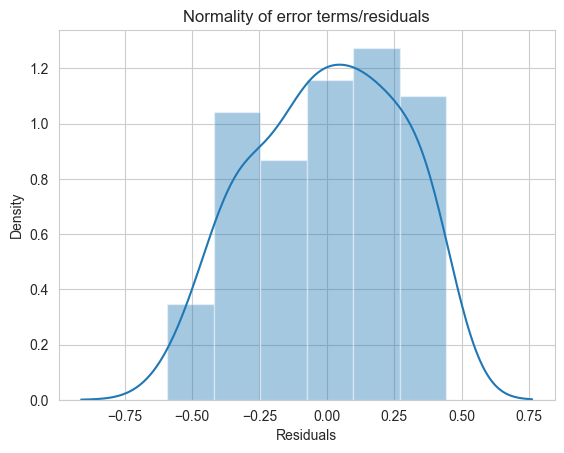

In [51]:
# Residual Analysis
# Distribution of errors
p = sns.distplot(res, kde=True)

p = plt.title("Normality of error terms/residuals")
plt.xlabel("Residuals")
plt.show()

In [42]:
data = dfPolynomial.copy()
y_res = res

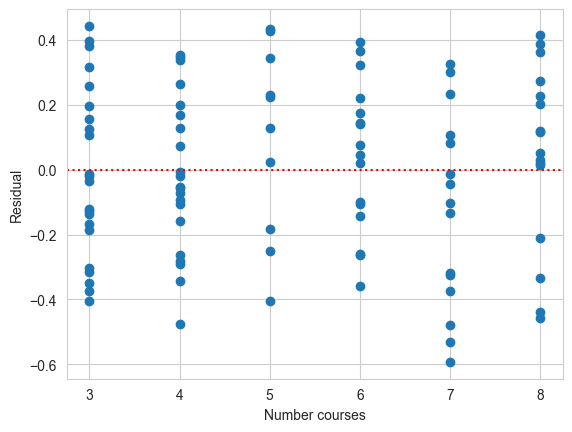

In [43]:
data["res"] = y_res
plt.scatter(data["number_courses"], data["res"])
plt.axhline(y=0, color="r", linestyle=":")
plt.xlabel("Number courses")
plt.ylabel("Residual")
plt.show()

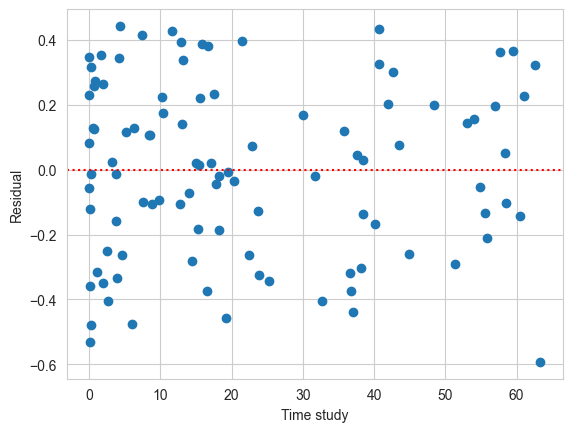

In [44]:
plt.scatter(data["time_study_squared"], data["res"])
plt.axhline(y=0, color="r", linestyle=":")
plt.xlabel("Time study")
plt.ylabel("Residual")
plt.show()

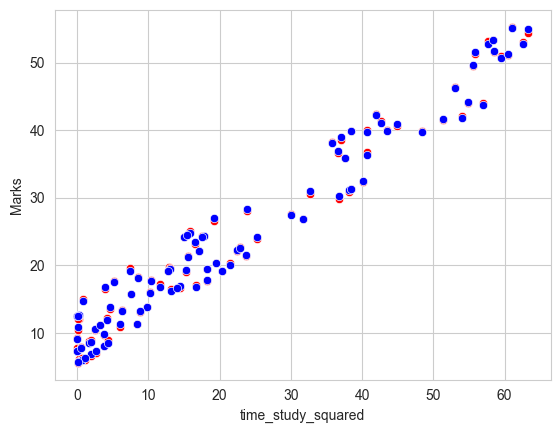

In [48]:
sns.scatterplot(x=X["time_study_squared"], y=y, color="red")
sns.scatterplot(x=X["time_study_squared"], y=y_pred, color="blue")
plt.show()

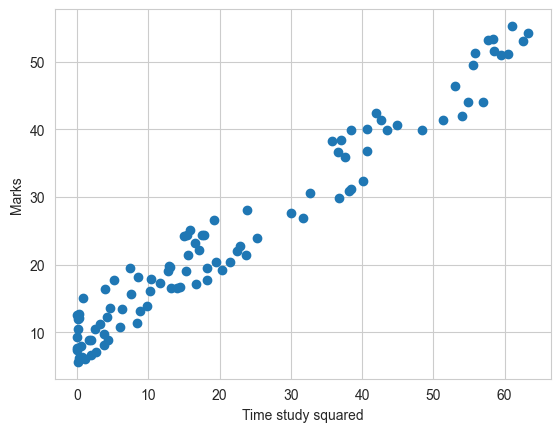

In [52]:
plt.scatter(data["time_study_squared"], data["Marks"])
plt.xlabel("Time study squared")
plt.ylabel("Marks")
plt.show()

d## Predictions on file Example1

In [53]:
df = pd.read_csv("Example1.csv")
df.head(10)

,time,distance
0,1,0.419660
1,2,1.350692
2,3,2.470342
3,4,1.566856
4,5,1.595280
5,6,2.227337
6,7,2.513842
7,8,2.792763
8,9,2.760862
9,10,3.507442


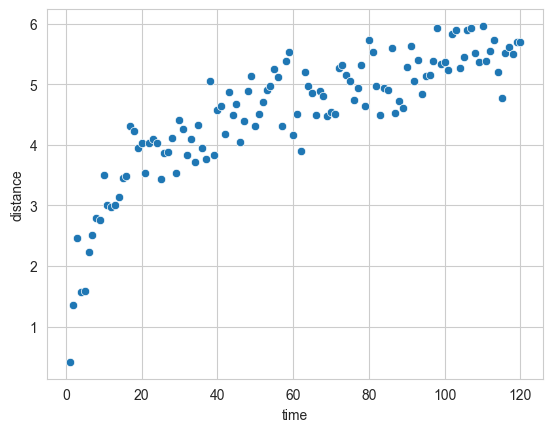

In [54]:
sns.scatterplot(df, x="time", y="distance")
plt.show()

### Observations: The above distribution seems to be following an exponential curve
1. Let's build 2 models, first linear
2. Then if we see a non linearity of residuals we will build a log transformation for the same

In [55]:
lm = LinearRegression()
# Splitting the dataset into X and y
X = np.array(df["time"]).reshape(-1, 1)
y = np.array(df["distance"]).reshape(-1, 1)

In [56]:
lm.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [57]:
y_pred2 = lm.predict(X)
# Accuracy
print(f"Accuracy: {r2_score(y,y_pred2)}")

Accuracy: 0.7019700219367477


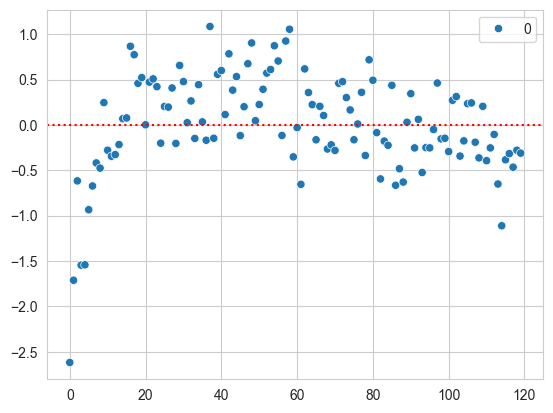

In [59]:
# Residual Analysis
res = y - y_pred2
sns.scatterplot(res)
plt.axhline(y=0, color="r", linestyle=":")
plt.show()

In [61]:
X

array([[  1],
       [  2],
       [  3],
       [  4],
       [  5],
       [  6],
       [  7],
       [  8],
       [  9],
       [ 10],
       [ 11],
       [ 12],
       [ 13],
       [ 14],
       [ 15],
       [ 16],
       [ 17],
       [ 18],
       [ 19],
       [ 20],
       [ 21],
       [ 22],
       [ 23],
       [ 24],
       [ 25],
       [ 26],
       [ 27],
       [ 28],
       [ 29],
       [ 30],
       [ 31],
       [ 32],
       [ 33],
       [ 34],
       [ 35],
       [ 36],
       [ 37],
       [ 38],
       [ 39],
       [ 40],
       [ 41],
       [ 42],
       [ 43],
       [ 44],
       [ 45],
       [ 46],
       [ 47],
       [ 48],
       [ 49],
       [ 50],
       [ 51],
       [ 52],
       [ 53],
       [ 54],
       [ 55],
       [ 56],
       [ 57],
       [ 58],
       [ 59],
       [ 60],
       [ 61],
       [ 62],
       [ 63],
       [ 64],
       [ 65],
       [ 66],
       [ 67],
       [ 68],
       [ 69],
       [ 70],
       [ 71],
      

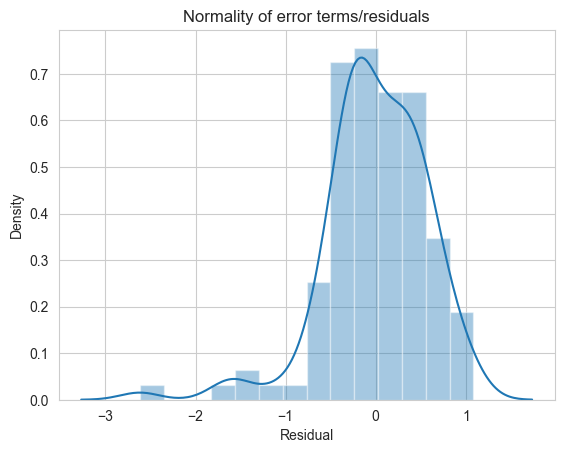

In [62]:
p = sns.distplot(res, kde=True)
p = plt.title("Normality of error terms/residuals")
plt.xlabel("Residual")
plt.show()

In [75]:
df["time_log"] = np.log(df["time"])
lm_log = LinearRegression()
X = df[["time", "time_log"]]
y = df["distance"]
lm_log.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [76]:
y_pred_log = lm_log.predict(X)
print(f"Accuracy: {r2_score(y,y_pred_log)}")

Accuracy: 0.8717944021704661


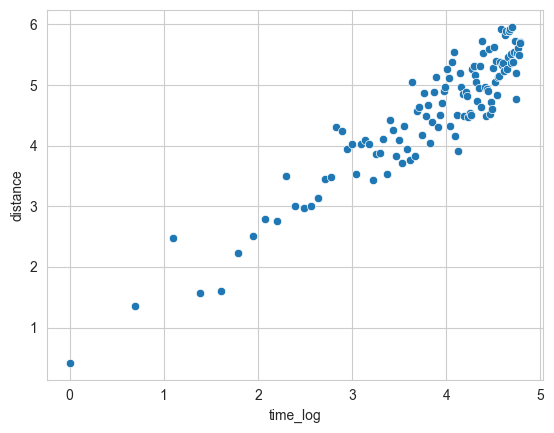

In [77]:
sns.scatterplot(df, x="time_log", y="distance")
plt.show()

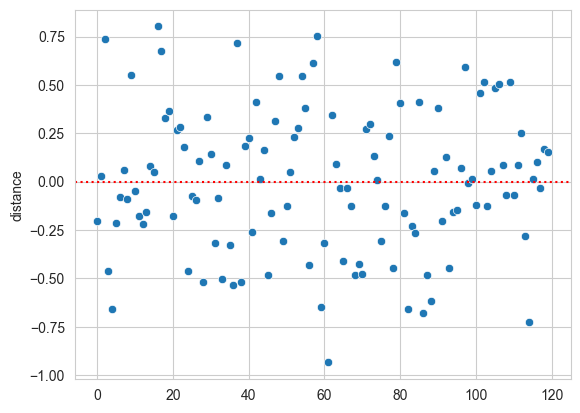

In [78]:
res_log = y - y_pred_log
sns.scatterplot(res_log)
plt.axhline(y=0, color="r", linestyle=":")
plt.show()

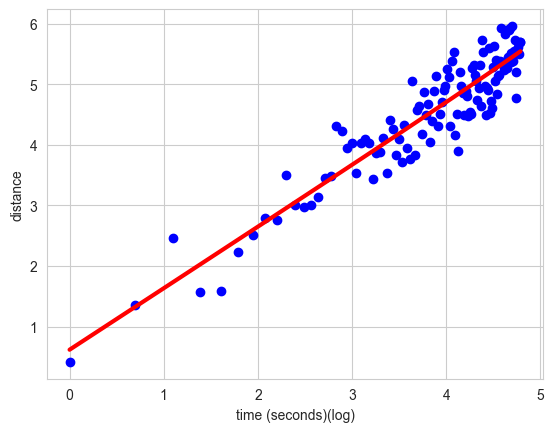

In [81]:
plt.scatter(X["time_log"], y, color="blue")
plt.plot(X["time_log"], y_pred_log, color="red", linewidth=3)
plt.xlabel("time (seconds)(log)")

plt.ylabel("distance")
plt.show()

### We can clearly see a linear relationship now

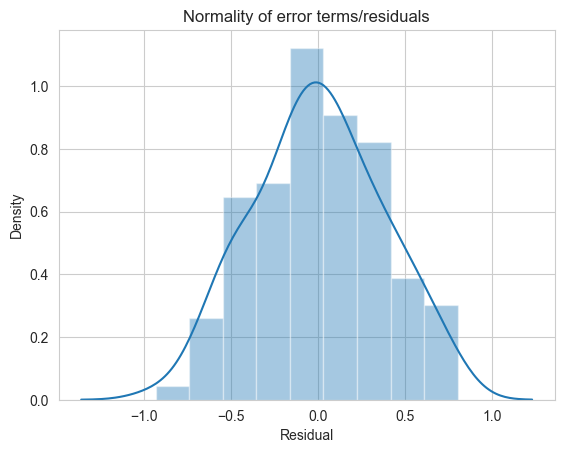

In [83]:
p = sns.distplot(res_log, kde=True)
p = plt.title("Normality of error terms/residuals")
plt.xlabel("Residual")
plt.show()